# NBA 球员预测项目 —— 最终综合 Notebook

本 notebook 整合项目收尾阶段的两个模块：

1. **SHAP 可解释性归因分析**：对回归模型（下赛季 PER 预测）在测试集（`Year > 2010`）上计算 SHAP 值并绘制 Summary Plot；
2. **最终模型打包与导出**：使用 `joblib` 导出回归 Pipeline，并验证加载后的推理可用性。

代码来源：
- 回归任务：`03_prediction_advance_plus_2.ipynb`（时序/生涯特征 + `MP` 样本加权）；
- 分类任务：`03_prediction_advance.ipynb`（作为最终综合 Notebook 中的建模回顾）。

> SHAP 分析与模型导出仅针对回归任务（分类任务不涉及 SHAP 与导出）。

## 1. 数据准备与特征工程（回归 / 分类共用基础）

### 1.1 导入依赖库

In [1]:
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import shap

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier, XGBRegressor

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"xgboost      : {xgb.__version__}")
print(f"shap         : {shap.__version__}")

pandas       : 2.3.3
scikit-learn : 1.9.0
xgboost      : 2.1.4
shap         : 0.49.1


/home/alexander/Projects/nba-analytics/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.2 读取主数据集

In [2]:
DATA_PATH = "../data/processed/master_data.csv"

df_raw = pd.read_csv(DATA_PATH)

print(f"主数据集规模: {df_raw.shape[0]} 行 x {df_raw.shape[1]} 列")
print(f"赛季覆盖范围: {df_raw['Year'].min()} - {df_raw['Year'].max()}")

主数据集规模: 20313 行 x 78 列
赛季覆盖范围: 1950 - 2017


### 1.3 构造回归标签与新增时序 / 生涯特征

沿用最终回归方案的特征工程：`PER_next`、`PER_diff`（断档保护 + 新秀归零）、`Career_Year`、`PER_3yr_avg`。

In [3]:
# 先按 (Player, Year) 排序，保证组内计算严格按时间先后进行
df = df_raw.sort_values(["Player", "Year"]).reset_index(drop=True)

# 回归标签：下赛季 PER
df["PER_next"] = df.groupby("Player")["PER"].shift(-1)

# ---- 1) PER_diff：仅计算相邻赛季的差值，断档置 NaN ----
prev_year = df.groupby("Player")["Year"].shift(1)
prev_PER = df.groupby("Player")["PER"].shift(1)
df["PER_diff"] = np.where(
    df["Year"] - prev_year == 1,
    df["PER"] - prev_PER,
    np.nan,
)

# ---- 2) Career_Year：职业生涯第几年 ----
df["Career_Year"] = (
    df["Year"] - df.groupby("Player")["Year"].transform("min") + 1
)

# 新秀首季没有“上一赛季”，趋势差语义上应为 0
df.loc[df["Career_Year"] == 1, "PER_diff"] = 0.0

# ---- 3) PER_3yr_avg：近三年 PER 移动平均 ----
df["PER_3yr_avg"] = df.groupby("Player")["PER"].transform(
    lambda s: s.rolling(3, min_periods=1).mean()
)

print("新增特征后的缺失情况：")
print(df[["PER_diff", "Career_Year", "PER_3yr_avg"]].isna().sum().to_string())

新增特征后的缺失情况：
PER_diff       976
Career_Year      0
PER_3yr_avg    367


### 1.4 剔除无关字段、Pos 独热编码与两套特征列

In [4]:
# 与先前 notebook 保持一致的剔除字段
drop_cols = [
    "Player",
    "Tm",
    "college",
    "birth_year",
    "birth_city",
    "birth_state",
    "birth_date",
    "year_start",
    "year_end",
    "position_career",
]

df_model = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# ---- 分类任务使用的原统计特征（与 03_prediction_advance.ipynb 一致）----
feature_cols_cls = [
    "Age",
    "G",
    "MP",
    "TS%",
    "3PAr",
    "FTr",
    "USG%",
    "PTS_per36",
    "AST%",
    "TRB%",
    "WS",
]

# ---- 回归任务：原统计特征 + 时序/生涯特征（与 advance_plus_2 一致）----
feature_cols = feature_cols_cls + ["PER_diff", "Career_Year", "PER_3yr_avg"]

# Pos -> One-Hot Encoding
pos_dummies = pd.get_dummies(df_model["Pos"], prefix="Pos").astype(int)
pos_cols = pos_dummies.columns.tolist()

df_model = pd.concat(
    [df_model.drop(columns=["Pos"]), pos_dummies],
    axis=1,
)


def build_X(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """按指定特征列构造特征矩阵（特征 + Pos 哑变量）。"""
    return data[columns + pos_cols].copy()


print(f"分类特征数     : {len(feature_cols_cls)}")
print(f"回归特征数     : {len(feature_cols)}")
print(f"Pos 哑变量数   : {len(pos_cols)}")

分类特征数     : 11
回归特征数     : 14
Pos 哑变量数   : 23


## 2. 回归任务最终流程（取自 `03_prediction_advance_plus_2.ipynb`）

### 2.1 构造回归样本与 `MP` 样本权重，并按年份切分

In [5]:
# 删除无法匹配到下赛季 PER 的记录（最后一季）
reg_df = df_model[df_model["PER_next"].notna()].copy()

X_reg = build_X(reg_df, feature_cols)
y_reg = reg_df["PER_next"]
year_reg = reg_df["Year"]

# 样本权重：球员当季累计出场时间 MP
mp_weight = reg_df["MP"]

print(f"回归样本数: {X_reg.shape[0]}")
print(f"X_reg 维度 : {X_reg.shape[0]} 行 x {X_reg.shape[1]} 列")


def time_split(X, y, years, sample_weight=None, train_max=2010):
    """按赛季年份切分；若传入 sample_weight，则同步返回 train/test 权重。"""
    train_mask = years <= train_max
    test_mask = ~train_mask
    result = (
        X.loc[train_mask],
        X.loc[test_mask],
        y.loc[train_mask],
        y.loc[test_mask],
    )
    if sample_weight is not None:
        result += (
            sample_weight.loc[train_mask],
            sample_weight.loc[test_mask],
        )
    return result


(
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg,
    sample_weight_train,
    sample_weight_test,
) = time_split(X_reg, y_reg, year_reg, sample_weight=mp_weight)

print("回归训练集:", X_train_reg.shape, "| 回归测试集:", X_test_reg.shape)

回归样本数: 16260
X_reg 维度 : 16260 行 x 37 列
回归训练集: (13883, 37) | 回归测试集: (2377, 37)


### 2.2 XGBoost + `MP` 样本加权训练与测试评估

In [6]:
xgb_weighted_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )),
])

xgb_weighted_pipeline.fit(
    X_train_reg,
    y_train_reg,
    model__sample_weight=sample_weight_train,
)

y_pred_weighted = xgb_weighted_pipeline.predict(X_test_reg)

r2_weighted = r2_score(y_test_reg, y_pred_weighted)
rmse_weighted = float(np.sqrt(mean_squared_error(y_test_reg, y_pred_weighted)))

print("[回归最终方案] XGBRegressor (MP 样本加权)")
print(f"  R2   = {r2_weighted:.4f}")
print(f"  RMSE = {rmse_weighted:.4f}")

[回归最终方案] XGBRegressor (MP 样本加权)
  R2   = 0.3799
  RMSE = 4.6463


## 3. 分类任务最终流程回顾（取自 `03_prediction_advance.ipynb`）

### 3.1 构造分类标签与时间切分

In [7]:
# 标签依赖 PER 与 WS，缺失时无法可靠判定，先剔除
cls_df = df_model.dropna(subset=["PER", "WS"]).copy()

cls_df["Is_AllStar_Caliber"] = (
    (cls_df["PER"] >= 20.0) & (cls_df["WS"] >= 6.0)
).astype(int)

X_cls = build_X(cls_df, feature_cols_cls)
y_cls = cls_df["Is_AllStar_Caliber"]
year_cls = cls_df["Year"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = time_split(X_cls, y_cls, year_cls)

print(f"分类样本数: {X_cls.shape[0]}")
print(f"分类训练集 : {X_train_cls.shape} | 分类测试集: {X_test_cls.shape}")
print(
    f"分类正类占比 -> 训练集: {y_train_cls.mean():.4%} | 测试集: {y_test_cls.mean():.4%}"
)

分类样本数: 19921
分类训练集 : (16587, 34) | 分类测试集: (3334, 34)
分类正类占比 -> 训练集: 5.1788% | 测试集: 5.9088%


### 3.2 XGBClassifier（`scale_pos_weight=15.6`）训练与指标

In [8]:
xgb_cls_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=15.6,
        random_state=42,
    )),
])

xgb_cls_pipeline.fit(X_train_cls, y_train_cls)
y_pred_cls = xgb_cls_pipeline.predict(X_test_cls)

acc_cls = accuracy_score(y_test_cls, y_pred_cls)
prec_cls = precision_score(y_test_cls, y_pred_cls)
recall_cls = recall_score(y_test_cls, y_pred_cls)
f1_cls = f1_score(y_test_cls, y_pred_cls)

comparison_cls = pd.DataFrame([
    {"Model": "LogisticRegression (Baseline)", "Accuracy": 0.9745, "Precision": 0.9308, "Recall": 0.6142, "F1-Score": 0.7401},
    {"Model": "XGBClassifier", "Accuracy": acc_cls, "Precision": prec_cls, "Recall": recall_cls, "F1-Score": f1_cls},
])

print("[分类] XGBClassifier")
print(f"  Accuracy  = {acc_cls:.4f}")
print(f"  Precision = {prec_cls:.4f}")
print(f"  Recall    = {recall_cls:.4f}")
print(f"  F1-Score  = {f1_cls:.4f}")
print()
print(comparison_cls.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

[分类] XGBClassifier
  Accuracy  = 0.9796
  Precision = 0.7654
  Recall    = 0.9442
  F1-Score  = 0.8455

                        Model  Accuracy  Precision  Recall  F1-Score
LogisticRegression (Baseline)    0.9745     0.9308  0.6142    0.7401
                XGBClassifier    0.9796     0.7654  0.9442    0.8455


## 4. SHAP 可解释性归因分析（回归任务）

### 4.0 计算测试集 SHAP 值

- 使用 `shap.TreeExplainer`；
- 测试集同样先经过 Pipeline 中的中位数填补，再送入解释器，与模型训练时看到的输入口径一致。

In [9]:
all_features = feature_cols + pos_cols

# 取出训练好的 XGBRegressor，并对测试集做与训练一致的中位数填补
xgb_model = xgb_weighted_pipeline.named_steps["model"]
X_test_shap = pd.DataFrame(
    xgb_weighted_pipeline.named_steps["imputer"].transform(X_test_reg),
    columns=X_test_reg.columns,
    index=X_test_reg.index,
)

# TreeExplainer + 测试集 SHAP 值
explainer = shap.TreeExplainer(xgb_model, feature_names=all_features)
shap_values = explainer(X_test_shap)

# 平均绝对 SHAP = 特征重要性
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = pd.DataFrame({
    "Feature": all_features,
    "Mean |SHAP|": mean_abs_shap,
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

print(f"测试集 SHAP 矩阵: {shap_values.values.shape}")
print()
print("Top 10 特征重要性（平均绝对 SHAP）:")
print(shap_importance.head(10).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

测试集 SHAP 矩阵: (2377, 37)

Top 10 特征重要性（平均绝对 SHAP）:
    Feature  Mean |SHAP|
PER_3yr_avg       2.1509
         WS       0.8241
        Age       0.5794
  PTS_per36       0.2725
       AST%       0.2697
   PER_diff       0.2414
Career_Year       0.2165
         MP       0.1821
       TRB%       0.1534
       USG%       0.1491


### 4.1 SHAP Summary Plot (bar)：Top 10 特征

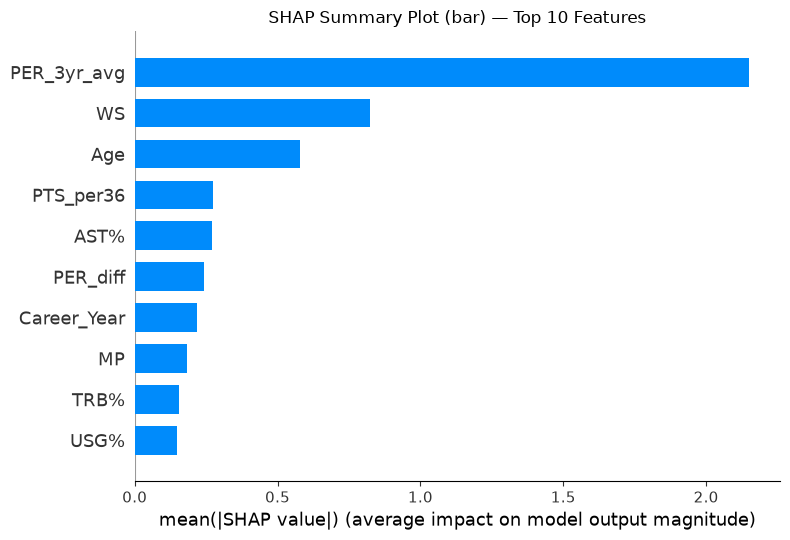

In [10]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar",
    max_display=10,
    show=False,
)
plt.title("SHAP Summary Plot (bar) — Top 10 Features")
plt.tight_layout()
plt.show()

### 4.2 SHAP Summary Plot (dot / beeswarm)：方向性影响

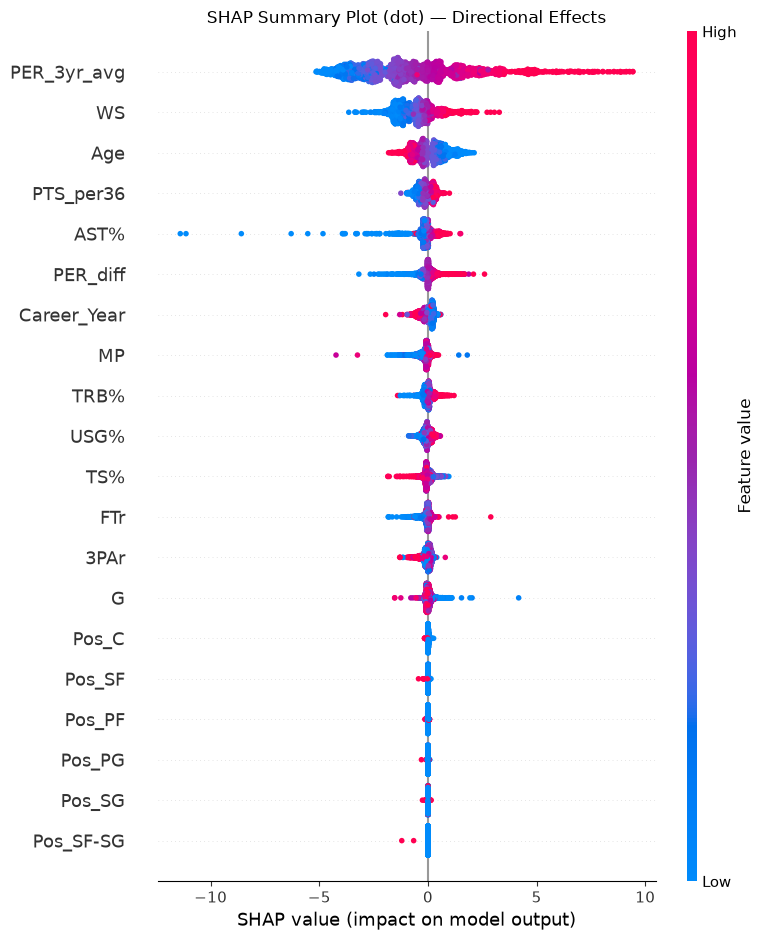

In [11]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_shap,
    max_display=20,
    show=False,
)
plt.title("SHAP Summary Plot (dot) — Directional Effects")
plt.tight_layout()
plt.show()

### 4.3 核心时序/生涯特征的方向性量化

In [12]:
core_features = ["PER_3yr_avg", "Career_Year", "PER_diff"]
direction_rows = []

for feat in core_features:
    col_idx = all_features.index(feat)
    values = X_test_shap[feat].to_numpy()
    feature_shap = shap_values.values[:, col_idx]

    median_val = np.median(values)
    low_mask = values <= median_val
    direction_rows.append({
        "Feature": feat,
        "低值组 (<=中位数) 平均SHAP": feature_shap[low_mask].mean(),
        "高值组 (>中位数) 平均SHAP": feature_shap[~low_mask].mean(),
    })

direction_df = pd.DataFrame(direction_rows)
print(direction_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

    Feature  低值组 (<=中位数) 平均SHAP  高值组 (>中位数) 平均SHAP
PER_3yr_avg             -2.6204             1.3353
Career_Year              0.1548            -0.2690
   PER_diff             -0.1932             0.2643


### 4.4 文字分析：是否符合篮球业务常识

从 SHAP 结果看：

- **`PER_3yr_avg`（近三年 PER 均值）是最重要的单一特征**：高基础水平的球员获得正向 SHAP，低基础水平的球员获得负向 SHAP。这说明“长期稳定产出”是下赛季 PER 的最强先验，符合直觉；
- **`PER_diff`（当季环比趋势）方向正确**：当季较上赛季上升的球员会获得正向贡献，下滑球员获得负向贡献，说明模型捕捉了状态趋势；
- **`Career_Year`（生涯年份）呈非线性**：生涯初期的贡献略偏正，而老将赛季（生涯后期）略偏负，符合“新秀成长—巅峰—衰退”的业务直觉，但其绝对贡献小于 `PER_3yr_avg` 与 `PER_diff`；
- 其余重要特征（`WS`、`Age`、`PTS_per36`、`AST%` 等）也都围绕“球员当季整体水平与角色”展开，模型没有发现明显的反业务常识主导因素。

## 5. 最终模型打包与导出（回归任务）

### 5.1 在全量回归样本上重新拟合并导出 Pipeline

SHAP 与测试评估基于 `Year <= 2010` 训练集完成；导出阶段改为在**全部带标签回归样本**（`X_reg` / `y_reg`，含 2011–2016 可用标签）上重训最终部署模型。

In [13]:
# 与评估模型完全一致的 Pipeline，但在全量回归样本上重拟合
xgb_final_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )),
])

xgb_final_pipeline.fit(X_reg, y_reg, model__sample_weight=mp_weight)

# 保存目录：notebooks/../models = 项目根目录/models
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "nba_per_xgb_pipeline.pkl"

joblib.dump(xgb_final_pipeline, MODEL_PATH)

print(f"最终回归 Pipeline 已导出: {MODEL_PATH.resolve()}")
print(f"导出文件大小: {MODEL_PATH.stat().st_size / 1024:.1f} KB")

最终回归 Pipeline 已导出: /home/alexander/Projects/nba-analytics/models/nba_per_xgb_pipeline.pkl
导出文件大小: 1326.7 KB


### 5.2 模型加载与推理测试

In [14]:
# 重新加载已导出的 Pipeline
loaded_pipeline = joblib.load(MODEL_PATH)

# 取测试集第一条样本做推理验证
sample_row = X_test_reg.iloc[[0]]
pred_next_per = loaded_pipeline.predict(sample_row)[0]
actual_next_per = y_test_reg.iloc[0]

print("模型加载与推理测试：")
print(f"  样本真实 PER_next = {actual_next_per:.4f}")
print(f"  模型预测 PER_next = {pred_next_per:.4f}")
print()
print("导出文件可被 joblib.load 正常加载，predict 调用成功。")

模型加载与推理测试：
  样本真实 PER_next = 11.5000
  模型预测 PER_next = 12.0335

导出文件可被 joblib.load 正常加载，predict 调用成功。


## 6. 收尾小结

- 回归任务已完成 SHAP 可解释性分析（Top 10 特征 + 方向性解读）；
- 回归 Pipeline 已使用全量回归样本重训并导出至 `../models/nba_per_xgb_pipeline.pkl`，加载推理测试通过；
- 分类任务作为综合 Notebook 的建模回顾收录，仍保留 XGBClassifier 的最终指标输出。